#0. Set up/Initialization
We will be using packages such as:


*   Numpy
*   pandas
*   Sklearn
*   Tensorflow
* Matplotlib





In [1]:
import warnings
warnings.filterwarnings('ignore')

In [17]:
%matplotlib inline

from pathlib import Path
from copy import deepcopy
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_curve

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Activation
from tensorflow.keras import optimizers

import matplotlib
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from mpl_toolkits.mplot3d import Axes3D  # 3D plots

import seaborn as sns

#1. Import Datasets

The data is already split into Train and Test sets. We will have to do some preprocessing such as:


*   Extract target variable "contaminated'
*   Normalize the data using StandardScaler() from sklearn



In [3]:
train = pd.read_csv('https://raw.githubusercontent.com/kngtm1/DATA607_WaterData_Project/refs/heads/main/data/train_set.csv')
test = pd.read_csv('https://raw.githubusercontent.com/kngtm1/DATA607_WaterData_Project/refs/heads/main/data/test_set.csv')

print(train.shape)
print(test.shape)


(8067, 26)
(2017, 26)


In [4]:
# Split into features and target for train set
X_train = train.drop(['contaminated'], axis=1)
y_train = train['contaminated']

In [5]:
#Normalization of features with StandardScaler
train_scaler = StandardScaler()
train_scaler.fit(X_train)
X_train = pd.DataFrame(train_scaler.transform(X_train), columns=X_train.columns)

In [6]:
# Split into features and target for test set
X_test = test.drop(['contaminated'], axis=1)
y_test = test['contaminated']

In [7]:
#Normalization of features with StandardScaler
test_scaler = StandardScaler()
test_scaler.fit(X_test)
X_test = pd.DataFrame(test_scaler.transform(X_test), columns=X_test.columns)

#2. Define NN Model using Tensorflow

We set up a Multi-Layer Perceptron

*   Input Layer: 150 Neurons
*   Hidden Layer: ReLu Activation -> 1 Neuron
*   Output Layer: Sigmoid Activation

We optimize the model using 'Adam' and we calculate our loss with binary cross entropy.

We will be using accuracy as our metric of evaluation.

In [8]:
model = Sequential([
    Dense(150, input_shape=(25,)),
    Activation('relu'),
    Dense(1),
    Activation('sigmoid')
])

In [9]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 150)            │         3,900 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 150)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           151 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 1)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,051 (15.82 KB)

 Trainable params: 4,051 (15.82 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

In [25]:
training=model.fit(X_train,
          y_train,
          epochs=50,
          validation_split=.2,
          batch_size=607,
          verbose=1,
          )

Epoch 1/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.8140 - loss: 0.4084 - val_accuracy: 0.7993 - val_loss: 0.4331
Epoch 2/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.8140 - loss: 0.4092 - val_accuracy: 0.7999 - val_loss: 0.4347
Epoch 3/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.8161 - loss: 0.4082 - val_accuracy: 0.8005 - val_loss: 0.4382
Epoch 4/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.8159 - loss: 0.4082 - val_accuracy: 0.7993 - val_loss: 0.4328
Epoch 5/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.8176 - loss: 0.4072 - val_accuracy: 0.8024 - val_loss: 0.4329
Epoch 6/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.8195 - loss: 0.4095 - val_accuracy: 0.7986 - val_loss: 0.4386
Epoch 7/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8164 - loss: 0.4075 - val_accuracy: 0.7974 - val_loss: 0.4384
Epoch 8/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.8148 - loss: 0.4070 - val_accuracy: 0.8011 - v

#3. Plot the Train and Validation Accuracy & Loss


*   Training and Validation are converging similarly. No sign of overfitting during model training




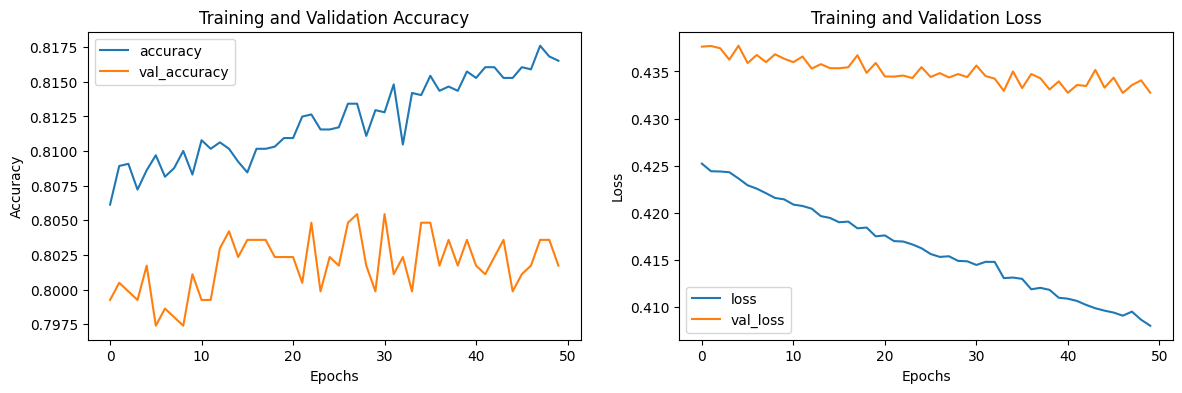

<Figure size 640x480 with 0 Axes>

In [24]:
fig, axes = plt.subplots(ncols=2, figsize=(14,4))
pd.DataFrame(training.history)[['accuracy', 'val_accuracy']].plot(ax=axes[0])
axes[0].set_title('Training and Validation Accuracy')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Accuracy')
pd.DataFrame(training.history)[['loss', 'val_loss']].plot(ax=axes[1])
axes[1].set_title('Training and Validation Loss')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Loss')
plt.show()
sns.despine()

#4. Evaluate Model Performance
We will be using Accuracy, Recall, and Precision to evaluate our NN model.

64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step


Text(0.5, 1.0, 'Confusion Matrix for Baseline Neural Network')

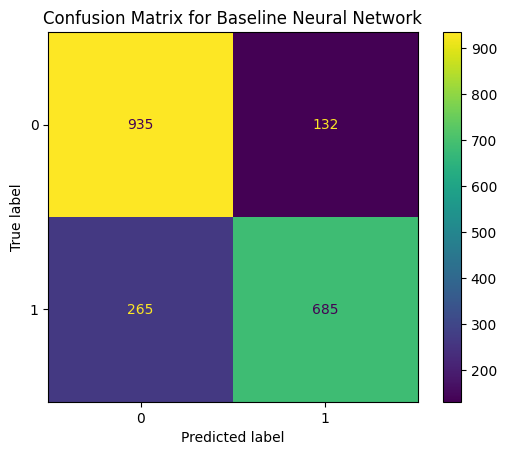

In [15]:
predicted = model.predict(X_test)

predicted = tf.squeeze(predicted)
predicted = np.array([1 if x >= 0.5 else 0 for x in predicted])
actual = np.array(y_test)
conf_mat = confusion_matrix(actual, predicted)
displ = ConfusionMatrixDisplay(confusion_matrix=conf_mat)
displ.plot()
displ.ax_.set_title('Confusion Matrix for Baseline Neural Network')


In [14]:
#Final Accuracy, Precision, and Recall Scores

accuracy = accuracy_score(y_test, predicted)
precision = precision_score(y_test, predicted)
recall = recall_score(y_test, predicted)
f1 = 2 * (precision * recall) / (precision + recall)

auc_metric = tf.keras.metrics.AUC()
auc_metric.update_state(y_test, predicted)
auc = auc_metric.result().numpy()


print(f'Accuracy: {accuracy}')
print(f'Precision: {precision}')
print(f'Recall: {recall}')
print(f'F1 Score: {f1}')
print(f'AUC: {auc}')


Accuracy: 0.8031730292513634
Precision: 0.8384332925336597
Recall: 0.7210526315789474
F1 Score: 0.7753254102999435
AUC: 0.7986706495285034


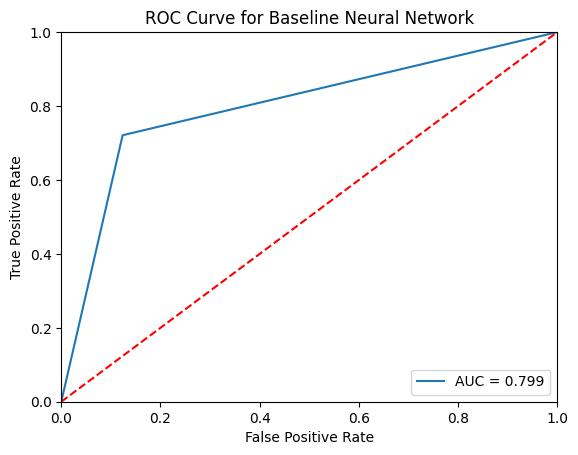

In [22]:
#ROC Curve

roc = tf.keras.metrics.AUC(curve='ROC')
roc.update_state(y_test, predicted)
roc_auc = roc.result().numpy()

fpr, tpr, thresholds = roc_curve(y_test, predicted)
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.3f}')
plt.legend(loc = 'lower right')
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Baseline Neural Network')
plt.xlabel('False Positive Rate')
plt.show()